In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
start = '2012-01-01'
end = '2025-01-01'
stock = 'GOOG'

data = yf.download(stock , start , end)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [3]:
data

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2012-01-03,16.495003,16.562926,16.171750,16.185882,147611217
2012-01-04,16.566145,16.614980,16.376260,16.485581,114989399
2012-01-05,16.336349,16.459304,16.267435,16.413692,131808205
2012-01-06,16.113499,16.360895,16.107796,16.339823,108119746
2012-01-09,15.430305,16.038633,15.399813,16.026237,233776981
...,...,...,...,...,...
2024-12-24,197.345184,197.445061,194.975874,195.946768,6809800
2024-12-26,196.875717,197.934509,195.647106,196.516126,7907900


In [4]:
data.reset_index(inplace = True) #change the index from date to index

In [5]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2012-01-03,16.495003,16.562926,16.171750,16.185882,147611217
1,2012-01-04,16.566145,16.614980,16.376260,16.485581,114989399
2,2012-01-05,16.336349,16.459304,16.267435,16.413692,131808205
3,2012-01-06,16.113499,16.360895,16.107796,16.339823,108119746
4,2012-01-09,15.430305,16.038633,15.399813,16.026237,233776981
...,...,...,...,...,...,...
3265,2024-12-24,197.345184,197.445061,194.975874,195.946768,6809800
3266,2024-12-26,196.875717,197.934509,195.647106,196.516126,7907900
3267,2024-12-27,193.819183,196.576052,191.753543,196.246426,14693000


In [6]:
ma_100_days = data['Close'].rolling(100).mean() # moving average for 100 days

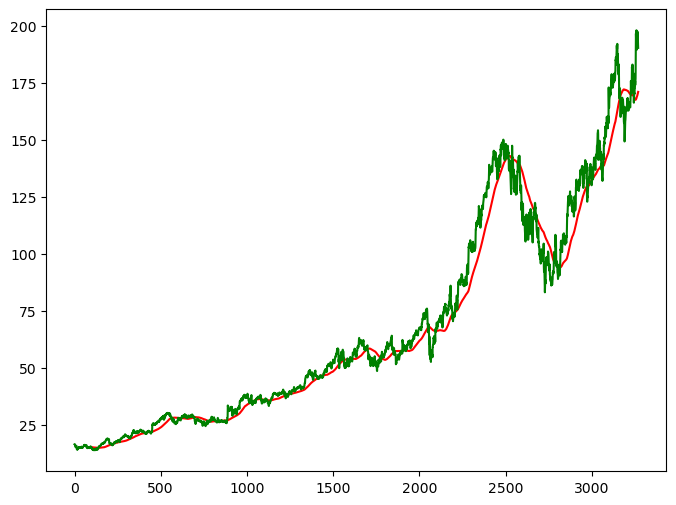

In [7]:
plt.figure(figsize = (8,6))
plt.plot(ma_100_days , 'r')
plt.plot(data['Close'] , 'g')
plt.show()

In [8]:
ma_200_days = data['Close'].rolling(200).mean()

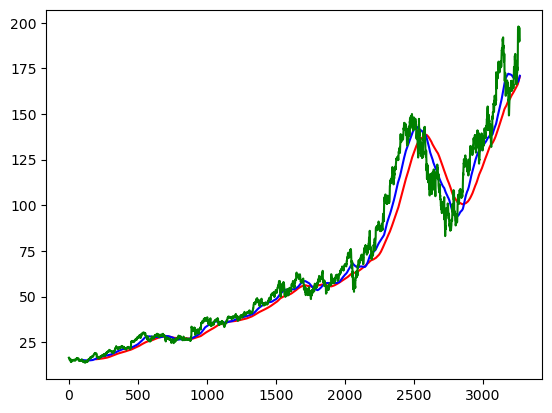

In [9]:
plt.plot(ma_200_days , 'r')
plt.plot(ma_100_days , 'b')
plt.plot(data['Close'] , 'g')
plt.show()

In [10]:
data.isna().sum()

Price   Ticker
Date              0
Close   GOOG      0
High    GOOG      0
Low     GOOG      0
Open    GOOG      0
Volume  GOOG      0
dtype: int64

In [11]:
X = data['Close'].copy()

In [12]:
X

Ticker,GOOG
0,16.495003
1,16.566145
2,16.336349
3,16.113499
4,15.430305
...,...
3265,197.345184
3266,196.875717
3267,193.819183
3268,192.470734


In [13]:
#scale data from 0 to 1
from sklearn.preprocessing import MinMaxScaler 
scaler = MinMaxScaler(feature_range = (0,1))
X = scaler.fit_transform(X)

In [14]:
data_train = X[0 : int(len(X) * 0.8)]
data_test = X[int(len(X) *0.8) : len(X)]

In [55]:
#create x and y for training
#x = past 100 days trend
#y = price at 101th day
x = []
y = []
for i in range(100 , len(data_train)):
    x.append(data_train[(i-100):i])
    y.append(data_train[i,0])

In [57]:
len(x) , len(y)

(2516, 2516)

In [58]:
x, y = np.array(x) , np.array(y)
x.shape , y.shape

((2516, 100, 1), (2516,))

In [61]:
#create a model
from keras.layers import Dense , Dropout , LSTM , Input
from keras.models import Sequential

In [63]:
model = Sequential()
model.add(Input(shape=(x.shape[1], 1)))

model.add(LSTM(units = 100 , activation = 'tanh'  , return_sequences = True , ))
model.add(Dropout(0.2))

model.add(LSTM(units = 150 , activation = 'tanh'  , return_sequences = True , ))
model.add(Dropout(0.2))

model.add(LSTM(units = 100 , activation = 'tanh'  , return_sequences = True , ))
model.add(Dropout(0.2))

model.add(LSTM(units = 200 , activation = 'tanh'  , return_sequences = True , ))
model.add(Dropout(0.2))

model.add(LSTM(units = 200 , activation = 'tanh'))
model.add(Dropout(0.3))

model.add(Dense(units = 1))
          

In [65]:
model.compile(optimizer = 'adam' , metrics = ['mae'] , loss = 'mean_squared_error')

In [67]:
model.fit(x , y , epochs = 5 , verbose = 1)

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 51s 503ms/step - loss: 0.0140 - mae: 0.0706
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 489ms/step - loss: 8.9124e-04 - mae: 0.0190
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 484ms/step - loss: 8.0190e-04 - mae: 0.0184
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 483ms/step - loss: 0.0011 - mae: 0.0221
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 477ms/step - loss: 0.0011 - mae: 0.0214


In [69]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 100, 100)       │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100, 150)       │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 150)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 100, 100)       │       100,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 100, 200)       │       240,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100, 200)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 200)            │       320,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,560,805 (9.77 MB)

 Trainable params: 853,601 (3.26 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,707,204 (6.51 MB)

In [71]:
data_test.shape

(654, 1)

In [73]:
x_test = []
y_test = []
for i in range(100 , data_test.shape[0]):
    x_test.append(data_test[(i-100) : i])
    y_test.append(data_test[i,0])
x_test = np.array(x_test)
y_test = np.array(y_test)
x_test.shape , y_test.shape
             

((554, 100, 1), (554,))

In [79]:
predicted = model.predict(x_test , verbose = 2)

18/18 - 4s - 195ms/step


In [115]:
pred_plot = scaler.inverse_transform(predicted)
truth_plot = scaler.inverse_transform([y_test])

In [121]:
truth_plot = truth_plot.flatten()

In [123]:
pred_plot.shape , truth_plot.shape

((554, 1), (554,))

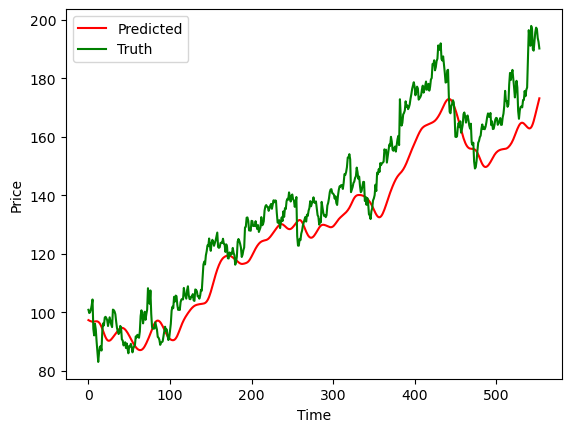

In [137]:
plt.plot(pred_plot , color = 'r' , label = 'Predicted')
plt.plot(truth_plot , color = 'g' , label = 'Truth')
plt.plot(label = 'label')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [140]:
model.save('predictions_model.keras')

In [142]:
import pickle

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)